## Phase separation

Reference: The Cahn–Hilliard–Navier–Stokes framework
for multiphase fluid flows: laminar, turbulent and active
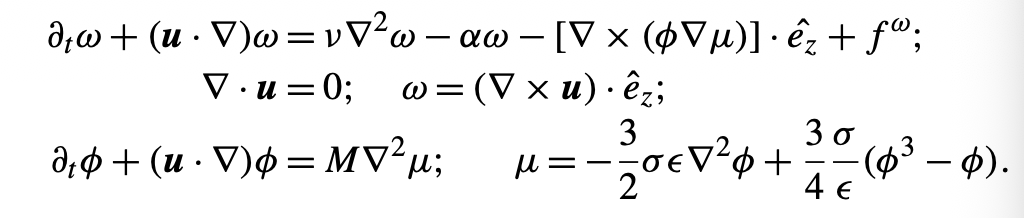
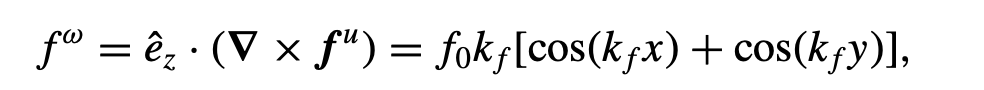
Reference: Interface-induced turbulence in viscous binary fluid mixtures
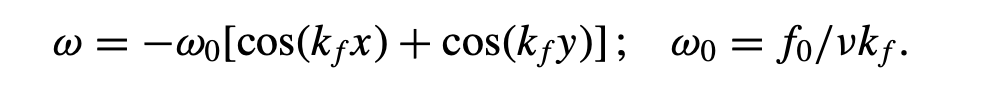
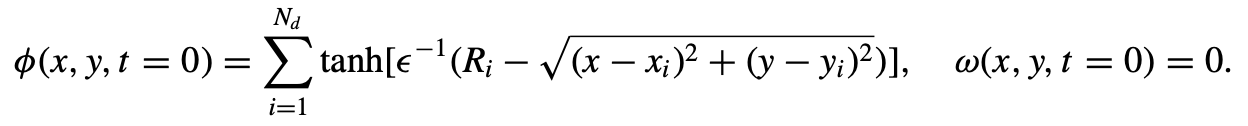

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la

In [2]:
## Grid has N^2 points (2D)
## Periodic domain (D = l^d), l = length of the side of d-dimensional hypercubic domain


# Domain 
L_x = 2*np.pi
L_y = 2*np.pi
N_x = 256
N_y = 256

# 2D periodic grid
del_x = L_x/N_x
del_y = L_y/N_y
x_j = np.arange(N_x) * del_x
y_j = np.arange(N_y) * del_y
X, Y = np.meshgrid(x_j, y_j, indexing='xy')

# Wrapped wavenumber arrays
n_x = np.arange(N_x)
n_y = np.arange(N_y)
k_x = (2*np.pi/L_x) * np.where(n_x <= N_x/2, n_x, n_x - N_x)
k_y = (2*np.pi/L_y) * np.where(n_y <= N_y/2, n_y, n_y - N_y)
Kx, Ky = np.meshgrid(k_x, k_y, indexing='xy')

K2 = Kx**2 + Ky**2

dx = 2*np.pi/N_x
# diffuse interface
epsilon = 4*dx
# 0.03

# Kinematic velocity
nu = 0.04
# Friction coefficient
alpha = 0
# Mobility in Cahn-Hilliard equation (epsilon**2)
M = epsilon**2
# 6*1e-4

# Low sigma could break the interface
sigma = 1.0

# \nu controls viscous damping in the vorticity equation
# alpha is an extra linear damping term
# M controls how strongly \phi diffuses through the chemical potential \mu

lamda_01 = -nu*K2 - alpha
lamda_02 = (-3/2)*M*sigma*epsilon*K2**2 + (3/4)*(sigma/epsilon)*M*K2 # M*sigma*epsilon*dt*K**4/2 or 3 must be less than 1, M and dt have inverse relation

# Reference for the following: Interface-induced turbulence in viscous binary fluid mixtures Supplemental Material
# Amplitude
f_0 = 0.1024 
# f_0 = 0.05
k_f = 4 # Wavenumber
# also epsilon, alpha, nu, M

# example droplet centers
centers = [
    (1.0, 1.0),
    (2.5, 4.0),
    (4.8, 2.2),
    (5.3, 5.1),
]

# example radii
radii = [0.35, 0.35, 0.35, 0.35]
# radii = [0.5, 0.5, 0.5, 0.5]

f_w = f_0 * k_f * (np.cos(k_f * X) + np.cos(k_f * Y))
f_w_hat = np.fft.fft2(f_w)

In [3]:
# Reference: Efficient Coding of the Minimum Image Convention
# Instead of the Euclidean distance, the minimum image convention is implemented for periodic BCs

def periodic_distance(X, Y, xc, yc, Lx, Ly):
    dx = X - xc
    dy = Y - yc
    # dx = (dx + Lx/2) % Lx - Lx/2
    # dy = (dy + Ly/2) % Ly - Ly/2
    return np.sqrt(dx**2 + dy**2)

def build_phi_rp2(X, Y, centers, radii, epsilon, Lx, Ly):
    phi = np.zeros_like(X)
    Nd = len(centers)

    for (xc, yc), R in zip(centers, radii):
        r = periodic_distance(X, Y, xc, yc, Lx, Ly)
        phi += np.tanh((R - r)/epsilon)

    phi += (Nd - 1)
    return phi

### CHNS equations in Fourier space
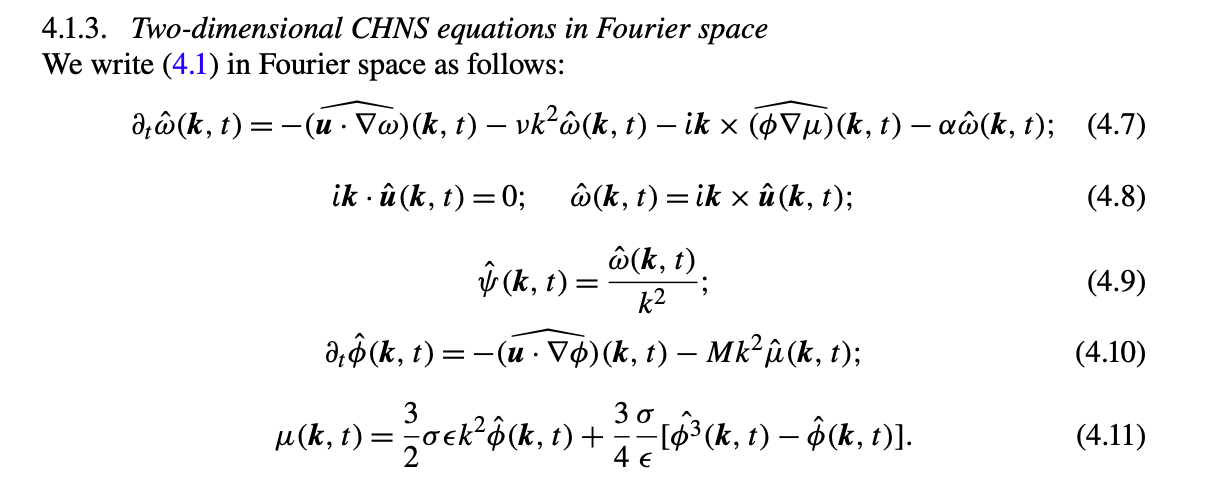

In [4]:
# Integer Fourier mode indices for dealiasing
mx = np.fft.fftfreq(N_x) * N_x
my = np.fft.fftfreq(N_y) * N_y
MX, MY = np.meshgrid(mx, my, indexing='xy')

# 1/2-dealiasing mask for cubic nonlinearities
dealias_mask = ((np.abs(MX) < N_x//4) & (np.abs(MY) < N_y//4)).astype(float)

def dealias(hat_field):
    return hat_field * dealias_mask

In [5]:
# Assemble \mu using pseudo-spectral implementation

# phi_x_y at t = 0
# phi_xy = build_phi_rp2(X, Y, centers, radii, epsilon, L_x, L_y)
phi_xy = np.zeros_like(X)
phi_xy_hat = np.fft.fft2(phi_xy)

print("initial phi stats:", phi_xy.min(), phi_xy.max(), np.mean(phi_xy))
print("initial phi hat finite?", np.isfinite(phi_xy_hat).all())

def mu_spec(phi_hat, phi_xy):
    phi3_hat = dealias(np.fft.fft2(phi_xy**3))
    return (3/2)*sigma*epsilon*K2*phi_hat + (3/4)*(sigma/epsilon)*(phi3_hat - phi_hat)



initial phi stats: 0.0 0.0 0.0
initial phi hat finite? True


In [ ]:
# omega = vorticity field

omega_xy_0 = np.zeros_like(phi_xy)
omega_hat = np.fft.fft2(omega_xy_0)

def recover_velocity(omega_hat):
    psi_hat = np.zeros_like(omega_hat, dtype=complex)
    mask = (K2 != 0)
    psi_hat[mask] = omega_hat[mask] / K2[mask]

    u_x_hat = 1j * Ky * psi_hat
    u_y_hat = -1j * Kx * psi_hat

    u_x = np.fft.ifft2(u_x_hat).real
    u_y = np.fft.ifft2(u_y_hat).real

    return u_x,u_y

In [7]:
# Handling Non linear terms in CHNS equation

def advection_phi(phi_xy_hat, u_x, u_y):
    phi_x = np.fft.ifft2(1j * Kx * phi_xy_hat).real
    phi_y = np.fft.ifft2(1j * Ky * phi_xy_hat).real
    adv_xy = phi_x * u_x + phi_y * u_y
    return dealias(np.fft.fft2(adv_xy))

def advection_omega(omega_hat, u_x, u_y):
    omega_x = np.fft.ifft2(1j * Kx * omega_hat).real
    omega_y = np.fft.ifft2(1j * Ky * omega_hat).real
    adv_xy = omega_x * u_x + omega_y * u_y
    return dealias(np.fft.fft2(adv_xy))

# 2D vorticity equation
def coupling_term(phi_xy, mu_spec):
    mu_x = np.fft.ifft2(1j * Kx * mu_spec).real
    mu_y = np.fft.ifft2(1j * Ky * mu_spec).real

    term1_hat = dealias(np.fft.fft2(phi_xy * mu_y))
    term2_hat = dealias(np.fft.fft2(phi_xy * mu_x))

    return 1j * Kx * term1_hat - 1j * Ky * term2_hat

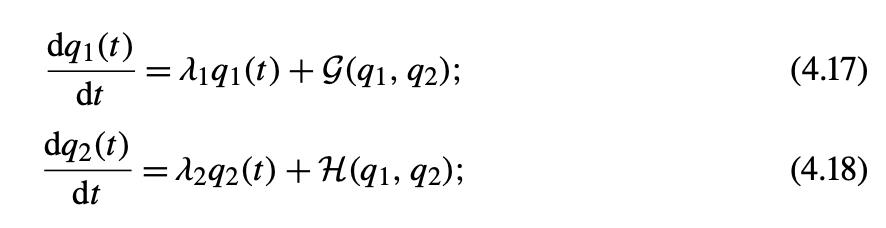
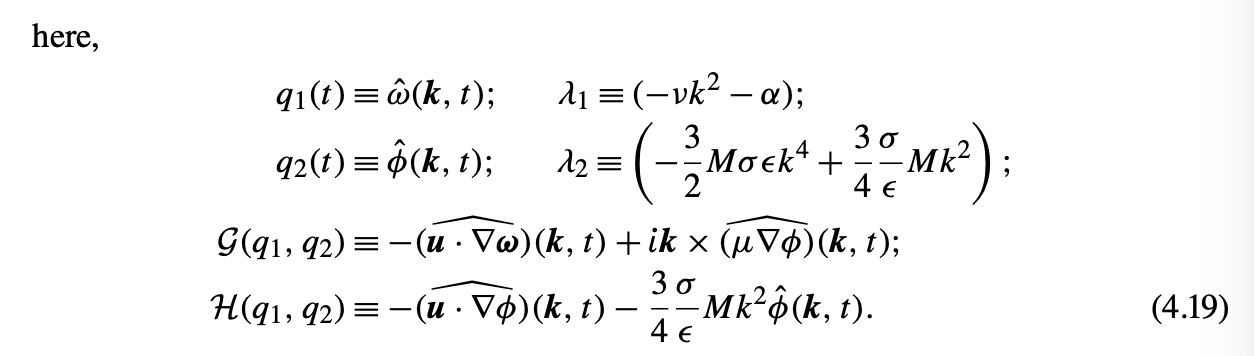

In [8]:
# Time stepping 

G = lambda omega_hat,phi_xy,mu_s,u_x,u_y: -(advection_omega(omega_hat,u_x,u_y)) + coupling_term(phi_xy,mu_s) + f_w_hat
H = lambda phi_xy_hat,phi_xy,u_x,u_y: -(advection_phi(phi_xy_hat,u_x,u_y)) - (3/4)*(sigma/epsilon)*M*K2*dealias(np.fft.fft2(phi_xy**3))


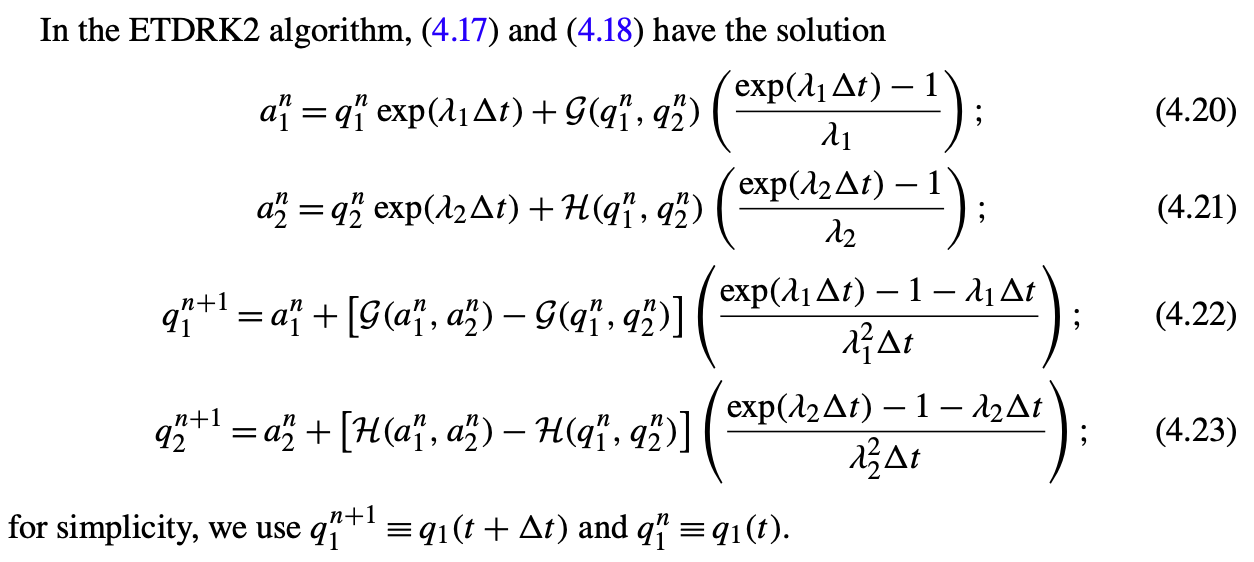

In [9]:
# Time stepping
T = 0.9
N_t = 200
delta_t = T/N_t

q_01 = omega_hat
q_02 = phi_xy_hat

q_01_n = q_01
q_02_n = q_02

omega_history = [omega_xy_0.copy()]
phi_history = [np.fft.ifft2(q_02_n).real.copy()]


# Masked handling for lambda = 0
E_01 = np.exp(lamda_01*delta_t)
E_02 = np.exp(lamda_02*delta_t)

mask_01 = (np.abs(lamda_01) > 1e-14)
mask_02 = (np.abs(lamda_02) > 1e-14)

# Masked handling for lambda = 0

phi1 = np.empty_like(lamda_01, dtype=complex)
phi2 = np.empty_like(lamda_02, dtype=complex)

phi1[mask_01] = (E_01[mask_01] - 1)/lamda_01[mask_01]
phi2[mask_02] = (E_02[mask_02] - 1)/lamda_02[mask_02]

phi1[~mask_01] = delta_t
phi2[~mask_02] = delta_t

phi_1 = np.empty_like(lamda_01, dtype=complex)
phi_2 = np.empty_like(lamda_02, dtype=complex)

phi_1[mask_01] = (E_01[mask_01] - 1 - lamda_01[mask_01] * delta_t)/(lamda_01[mask_01]**2 * delta_t)
phi_2[mask_02] = (E_02[mask_02] - 1 - lamda_02[mask_02] * delta_t)/(lamda_02[mask_02]**2 * delta_t)

phi_1[~mask_01] = 0.5 * delta_t
phi_2[~mask_02] = 0.5 * delta_t

for n in range(0,N_t):
    # Block A: Recomputation

    # A.1) Extracting velocity from omega_hat_n
    u_x_n,u_y_n = recover_velocity(q_01_n)

    # A.2) Re-computing terms
    phi_intermediate = np.fft.ifft2(q_02_n).real
    mu_spec_n = mu_spec(q_02_n,phi_intermediate)

    # A.3) Non-linear terms
    G_n = G(q_01_n,phi_intermediate,mu_spec_n,u_x_n,u_y_n)
    H_n = H(q_02_n,phi_intermediate,u_x_n,u_y_n)

    # Block B: Predictor

    a_01_n = q_01_n * np.exp(lamda_01 * delta_t) + (G_n * phi1)
    a_02_n = q_02_n * np.exp(lamda_02 * delta_t) + (H_n * phi2)

    # Block C: Intermediate state reconstruction
    # C.1) Recover velocity from a_01_n
    u_x_a, u_y_a = recover_velocity(a_01_n)

    # C.2) Recover phi from a_02_n
    phi_a = np.fft.ifft2(a_02_n).real
    mu_spec_a = mu_spec(a_02_n,phi_a)

    # Block D: Final assembly

    G_a = G(a_01_n,phi_a,mu_spec_a,u_x_a,u_y_a)
    H_a = H(a_02_n,phi_a,u_x_a,u_y_a)

    q_01_next = a_01_n + (G_a - G_n) * phi_1
    q_02_next = a_02_n + (H_a - H_n) * phi_2

    q_01_next = dealias(q_01_next)
    q_02_next = dealias(q_02_next)

    if not np.isfinite(q_01_next).all() or not np.isfinite(q_02_next).all():
        print("NaN first appears at step", n)
        print("q_01_n max abs:", np.nanmax(np.abs(q_01_n)))
        print("q_02_n max abs:", np.nanmax(np.abs(q_02_n)))
        break
    
    # Final omega hat
    q_01_n = q_01_next
    omega_history.append(np.fft.ifft2(q_01_n).real)

    # Final phi_hat
    q_02_n = q_02_next
    phi_history.append(np.fft.ifft2(q_02_n).real)

In [10]:
print("final phi stats:", phi_history[-1].min(), phi_history[-1].max(), np.mean(phi_history[-1]))
print("final omega stats:", omega_history[-1].min(), omega_history[-1].max())
print("all phi finite?", np.isfinite(np.array(phi_history)).all())
print("all omega finite?", np.isfinite(np.array(omega_history)).all())

final phi stats: 0.0 0.0 0.0
final omega stats: -0.5604576701480752 0.5604576701480751
all phi finite? True
all omega finite? True


In [11]:
# Pointers

## 1) may need to use Google Collab, numpy might be too slow
## 2) Validation Techniques - look up research papers on it - vary time-stepping techniques/grid points & compute the error 
## 3) Simulate phase separation
## 4) Look up on relations between parameters 
## 5) Additional - Mean square displacement

In [12]:
phi_mean = []

for i in range(len(phi_history)):
    phi_mean.append(np.mean(phi_history[i]))

phi_mean_check = np.array(phi_mean)   # one value per time step
m0 = phi_mean[0]

abs_drift = np.abs(phi_mean_check - m0)
rel_drift = abs_drift / max(abs(m0), 1e-14)

print("max abs drift =", abs_drift.max())
print("max rel drift =", rel_drift.max())
print(m0)


max abs drift = 0.0
max rel drift = 0.0
0.0


/opt/anaconda3/lib/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  func(*args, **kwargs)


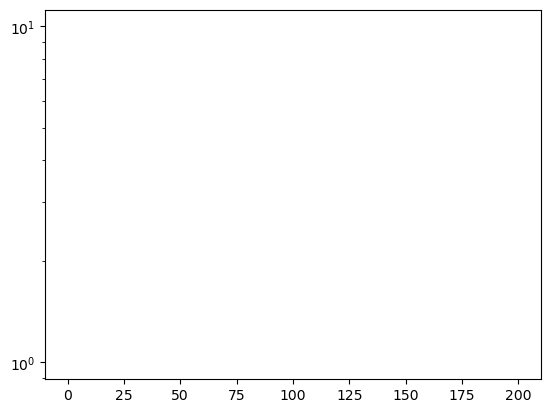

In [13]:
# Since m0 is almost close to roundoff-level zero, dividing by such a number results into 
# arbitrarily large output. Thus, we use abs_drift. 

plt.semilogy(abs_drift)
# plt.semilogy(rel_drift)

In [14]:
phi_max = []

for i in range(len(phi_history)):
    phi_max.append(np.max(np.abs(phi_history[i])))

omega_max = []

for i in range(len(omega_history)):
    omega_max.append(np.max(np.abs(omega_history[i])))

phi_max_check = np.array(phi_max)
omega_max_check = np.array(omega_max)

print("max |phi| =", phi_max_check.max())
print("max |omega| =", omega_max_check.max())
print("all finite phi?", np.isfinite(phi_max_check).all())
print("all finite omega?", np.isfinite(omega_max_check).all())


max |phi| = 0.0
max |omega| = 0.5604576701480752
all finite phi? True
all finite omega? True


Text(0.5, 1.0, 'max |omega| over time')

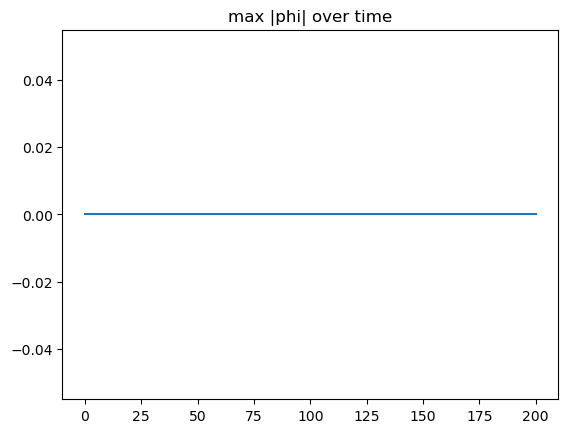

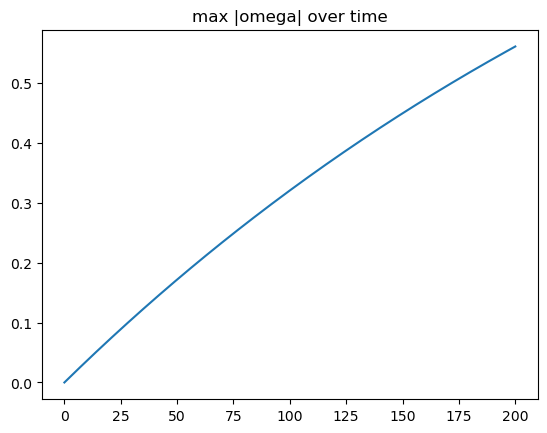

In [15]:
plt.plot(phi_max)
plt.title("max |phi| over time")

plt.figure()
plt.plot(omega_max)
plt.title("max |omega| over time")

In [16]:
omega_xy_final = np.fft.ifft2(q_01_n).real
phi_xy_final   = np.fft.ifft2(q_02_n).real

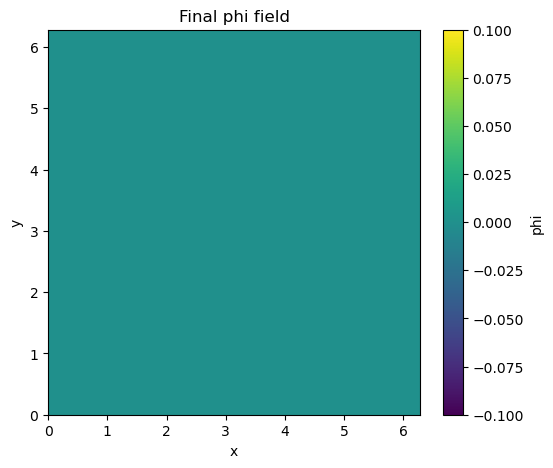

In [17]:
plt.figure(figsize=(6,5))
plt.imshow(phi_xy_final, origin='lower', extent=[0, L_x, 0, L_y], aspect='auto')
plt.colorbar(label='phi')
plt.title('Final phi field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

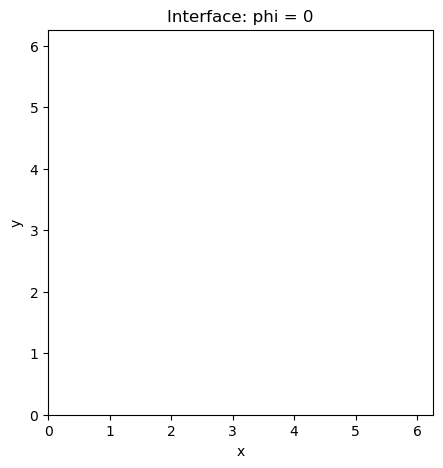

In [18]:
plt.figure(figsize=(6,5))
plt.contour(X, Y, phi_xy_final, levels=[0], colors='k')
plt.title('Interface: phi = 0')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.show()

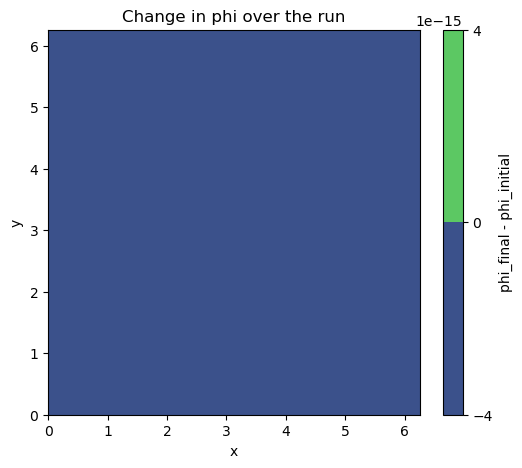

max change in phi = 0.0


In [19]:
phi_change = phi_history[-1] - phi_history[0]

plt.figure(figsize=(6,5))
plt.contourf(X, Y, phi_change, levels=50)
plt.colorbar(label='phi_final - phi_initial')
plt.title('Change in phi over the run')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

print("max change in phi =", np.max(np.abs(phi_change)))

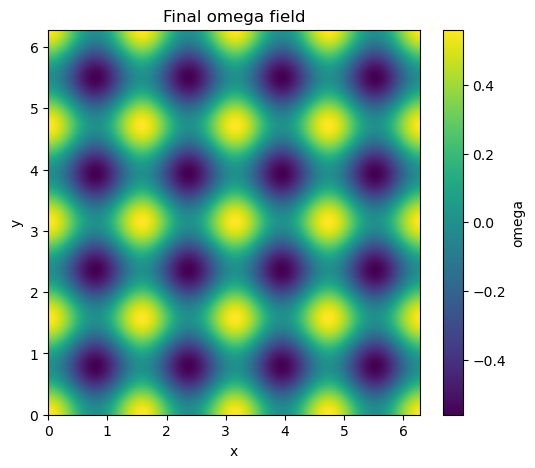

In [20]:
plt.figure(figsize=(6,5))
plt.imshow(omega_xy_final, origin='lower', extent=[0, L_x, 0, L_y], aspect='auto')
plt.colorbar(label='omega')
plt.title('Final omega field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

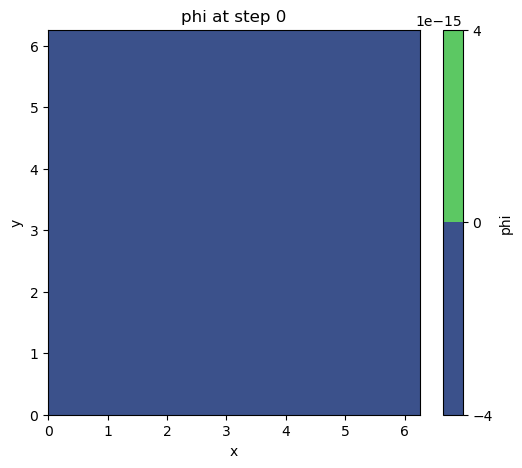

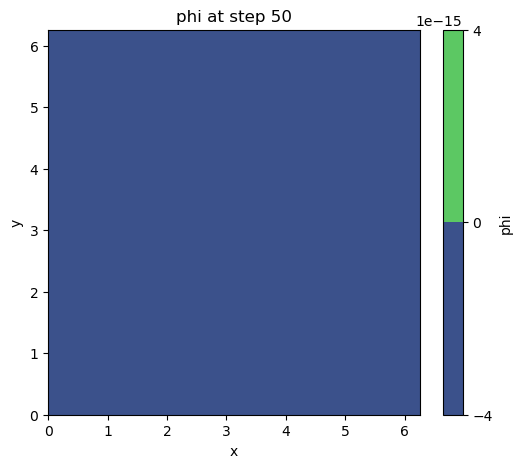

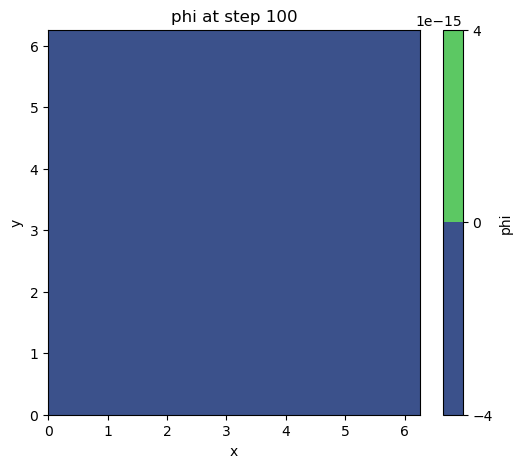

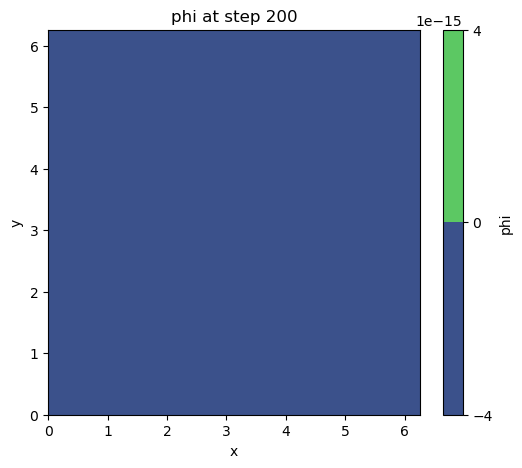

In [21]:
times_to_plot = [0, len(phi_history)//4,len(phi_history)//2, len(phi_history)-1]

for idx in times_to_plot:
    plt.figure(figsize=(6,5))
    plt.contourf(X, Y, phi_history[idx], levels=50)
    plt.colorbar(label='phi')
    plt.title(f'phi at step {idx}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

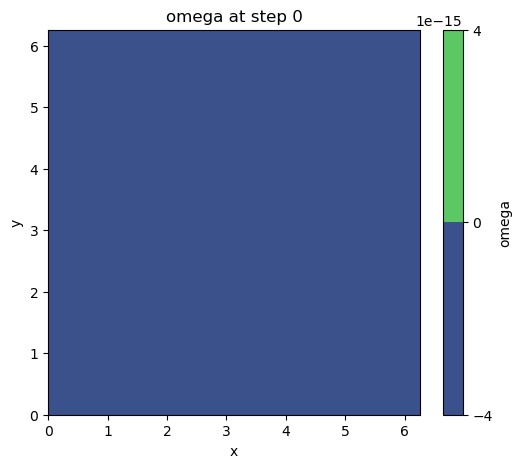

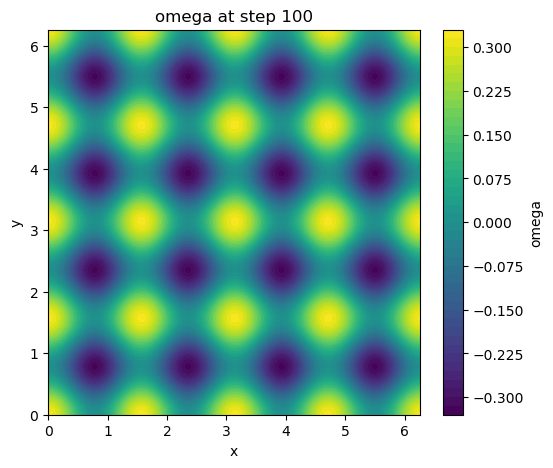

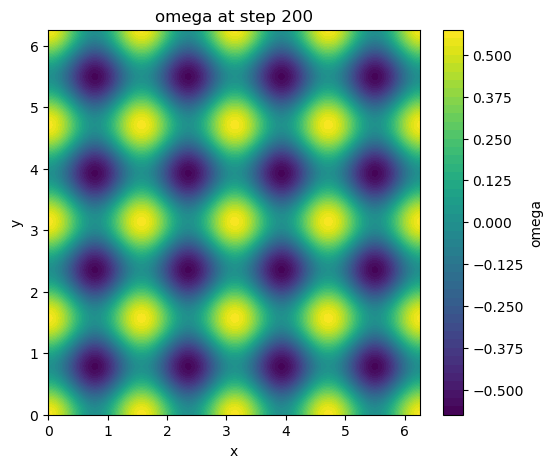

In [22]:
times_to_plot = [0, len(omega_history)//2, len(omega_history)-1]

for idx in times_to_plot:
    plt.figure(figsize=(6,5))
    plt.contourf(X, Y, omega_history[idx], levels=50)
    plt.colorbar(label='omega')
    plt.title(f'omega at step {idx}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

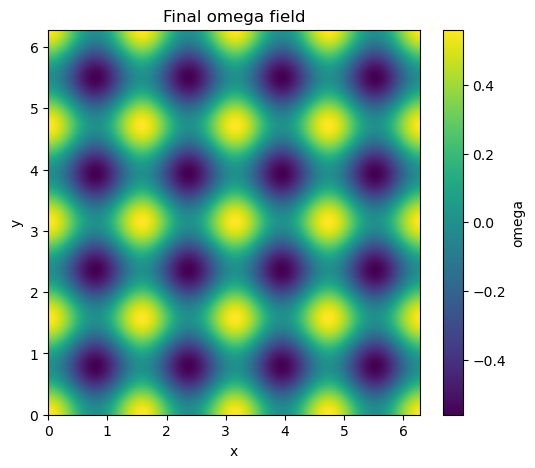

In [23]:
om = omega_xy_final
v = np.max(np.abs(om))

plt.figure(figsize=(6,5))
plt.imshow(om, origin='lower', extent=[0, L_x, 0, L_y], vmin=-v, vmax=v, aspect='auto')
plt.colorbar(label='omega')
plt.title('Final omega field')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [24]:
id="first_step_growth"
print(np.min(omega_history[0]), np.max(omega_history[0]))
print(np.min(omega_history[1]), np.max(omega_history[1]))

0.0 0.0
-0.0036810966764123524 0.0036810966764123524


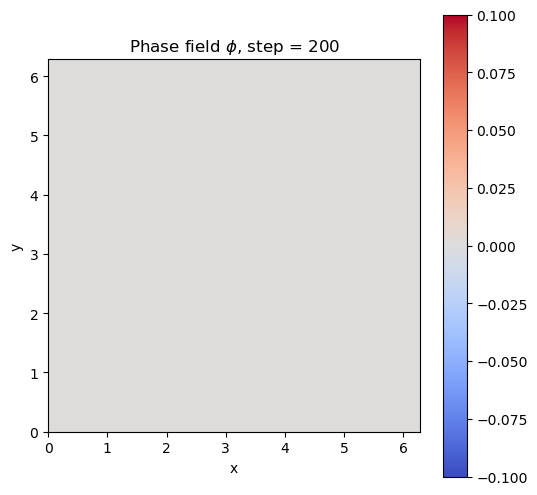

In [25]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(6,6))

im = ax.imshow(
    phi_history[0],
    origin='lower',
    extent=[0, L_x, 0, L_y],
    cmap='coolwarm',
    animated=True
)
ax.set_title("Phase field $\\phi$")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax)

def update(frame):
    im.set_array(phi_history[frame])
    ax.set_title(f"Phase field $\\phi$, step = {frame}")
    return [im]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(phi_history),
    interval=50,
    blit=True
)

ani.save("phi_animation.gif", writer="pillow", fps=15)
plt.show()

In [26]:
print(phi_history[0].min(), phi_history[0].max(), np.mean(phi_history[0]))

0.0 0.0 0.0


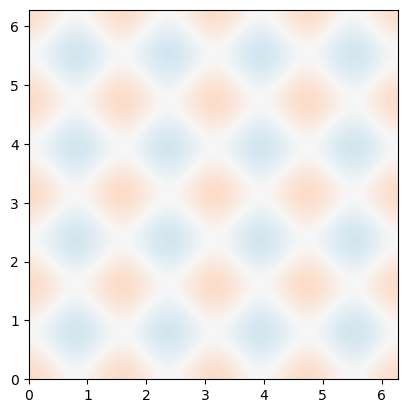

In [27]:
omega_plot = omega_history[200]
plt.imshow(omega_plot, origin='lower', extent=[0,L_x,0,L_y], cmap='RdBu_r', vmin=-3, vmax=3)

In [28]:
# Validation 02: Conservation and numerical stability

phi_mean_hist = [np.mean(phi) for phi in phi_history]
phi_min_hist  = [np.min(phi) for phi in phi_history]
phi_max_hist  = [np.max(phi) for phi in phi_history]

omega_min_hist = [np.min(w) for w in omega_history]
omega_max_hist = [np.max(w) for w in omega_history]

print("Mean phi drift =", np.max(np.abs(np.array(phi_mean_hist) - phi_mean_hist[0])))
print("All phi finite?  ", np.isfinite(np.array(phi_history)).all())
print("All omega finite?", np.isfinite(np.array(omega_history)).all())


Mean phi drift = 0.0
All phi finite?   True
All omega finite? True


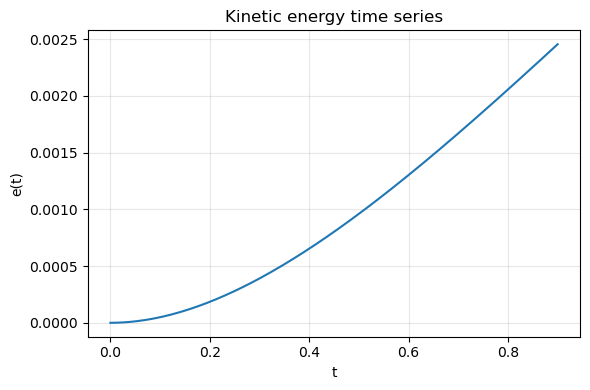

In [29]:
# Validation 03: Energy and coarsening diagnostics

# Kinetic energy
energy_hist = []

for w_hat in [np.fft.fft2(w) for w in omega_history]:
    u_x, u_y = recover_velocity(w_hat)
    e_t = 0.5 * np.mean(u_x**2 + u_y**2)
    energy_hist.append(e_t)

t_arr = np.arange(len(energy_hist)) * delta_t

plt.figure(figsize=(6,4))
plt.plot(t_arr, energy_hist, lw=1.5)
plt.xlabel("t")
plt.ylabel("e(t)")
plt.title("Kinetic energy time series")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()